# Irregular panels: a random effect with a clock

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/panel_irregular_kernel.ipynb)

Companion notebook to part 6 of the series on predictive modelling with panel data.

Parts 4 and 5 both used a random intercept: one draw per unit, shared by every row of that unit.
That is a statement about covariance, namely that a unit's rows are exchangeable, so a row
measured a day earlier and a row measured a year earlier say exactly the same thing about the row
you are predicting. When rows arrive on a regular grid you can drop that assumption with an AR(1)
term. When they do not, AR(1) itself stops applying: in `nlme`, `corAR1` documents that "a
covariate for this correlation structure must be integer valued", and its continuous time sibling
`corCAR1` exists precisely because real observation times are not integers. On the tree-based side
the choice does not arise: GPBoost has no temporal AR(1) at all, so a continuous time kernel is the
only route there is.

This notebook gives the random effect a clock, an exponential kernel over observation time fitted
independently per unit, and measures what changes: the variance decomposition, the accuracy, and
the width of the prediction interval as a function of how far ahead you are predicting. The kernel
turns out to be an addition to the intercept rather than a replacement for it, which one section
below is devoted to.

The panel is simulated so every quantity has a known truth. Arrival times are a Poisson process
per unit, so both the number of rows and the spacing between them differ across units. The unit
level process is Ornstein-Uhlenbeck in real time, with covariance `4.0 * exp(-|t - t'| / 3.0)`;
the noise variance is 1.0. The mean function is Friedman #1, the same one used in parts 4 and 5.

In [1]:
try:
    import gpboost
except ImportError:
    !pip install -q gpboost==1.7.4 lightgbm==4.7.0 matplotlib

In [2]:
import time, warnings
import numpy as np, pandas as pd
import gpboost as gpb, lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220, "display.max_columns", 40)
print("gpboost", gpb.__version__, "| lightgbm", lgb.__version__)

gpboost 1.7.4 | lightgbm 4.7.0


## The panel

`T_CUT` splits every unit by time rather than by row, so the number of training rows differs across
units and the distance from a unit's last training row to each held-out row is itself a
distribution. That distance, `gap`, is the quantity the rest of the notebook is about.

In [3]:
NG, T_WIN, T_CUT, LAM = 120, 12.0, 8.0, 1.0
SU, SE, RHO, Z90 = 2.0, 1.0, 3.0, 1.6448536269514722
M, K_FOLDS, NSEED = 200, 4, 5
N_REG = int(LAM * T_WIN)          # rows per unit on the regular control grid
FEAT = [f"x{i}" for i in range(5)]
BASE = {"objective": "regression_l2", "learning_rate": 0.05, "num_leaves": 31,
        "min_data_in_leaf": 20, "verbose": -1}


def F(X):
    f = 10*np.sin(np.pi*X[:, 0]*X[:, 1]) + 20*(X[:, 2]-0.5)**2 + 10*X[:, 3] + 5*X[:, 4]
    return (f - 14.4) / 2.5


def rmse(y, p):
    return float(np.sqrt(np.mean((y - p)**2)))


def coverage(y, mean, var):
    s = np.sqrt(np.maximum(var, 0.0))
    return float(np.mean((y >= mean - Z90*s) & (y <= mean + Z90*s)))


def qedges(x, nbin):
    e = np.quantile(x, np.linspace(0, 1, nbin + 1))
    e[-1] += 1e-9                        # so the largest value falls inside the last bin
    return e


def kern(a, b, var=SU**2):
    return var * np.exp(-np.abs(a[:, None] - b[None, :]) / RHO)


# perm is the variance of a permanent per-unit level, ou that of the drifting part
def make(seed, regular=False, perm=0.0, ou=SU**2):
    rng = np.random.default_rng(seed)
    fr = []
    for _ in range(NG * 3):
        t = (np.arange(1, N_REG + 1) * (T_WIN / N_REG) if regular
             else np.sort(rng.uniform(0, T_WIN, rng.poisson(LAM * T_WIN))))
        if (t <= T_CUT).sum() < 3 or (t > T_CUT).sum() < 1:
            continue
        b = np.linalg.cholesky(kern(t, t, ou) + 1e-9*np.eye(len(t))) @ rng.normal(size=len(t))
        if perm:
            b = b + rng.normal(0.0, np.sqrt(perm))
        X = rng.uniform(size=(len(t), 5))
        df = pd.DataFrame(X, columns=FEAT)
        df["unit"], df["t"], df["b"] = len(fr), t, b
        df["y"] = F(X) + b + rng.normal(0, SE, len(t))
        fr.append(df)
        if len(fr) == NG:
            break
    d = pd.concat(fr, ignore_index=True)
    d["is_tr"] = d.t <= T_CUT
    tl = d[d.is_tr].groupby("unit").t.max()
    d["gap"] = np.where(d.is_tr, np.nan, d.t - tl.reindex(d.unit).values)
    d["n_tr"] = d[d.is_tr].groupby("unit").size().reindex(d.unit).values
    return d


d0 = make(0)
n_tr = d0.groupby("unit").n_tr.first()
print(f"{d0.unit.nunique()} units, {len(d0)} rows, {int(d0.is_tr.sum())} training")
print(f"training rows per unit: {n_tr.min()} to {n_tr.max()}, mean {n_tr.mean():.1f}")
print(f"gap from the last training row: {d0.gap.min():.2f} to {d0.gap.max():.2f}, "
      f"median {d0.gap.median():.2f}")
print(f"sd(y) = {d0.y.std():.3f}, sd(unit process) = {d0.b.std():.3f}")

120 units, 1460 rows, 986 training
training rows per unit: 3 to 18, mean 8.2
gap from the last training row: 0.21 to 7.40, median 2.74
sd(y) = 2.876, sd(unit process) = 1.985


## The best any model could do

With the true covariance and a perfectly known mean function, the predictive distribution of a
held-out row given the unit's training rows is available in closed form. This is the reference both
fitted models are measured against, and the only curve here whose shape is not an estimate.

In [4]:
# variance of a new row at times b given training rows at times a, under the true covariance
def post_var(a, b):
    k = kern(b, a)
    return SU**2 + SE**2 - np.einsum("ij,ij->i", k, np.linalg.solve(
        kern(a, a) + SE**2*np.eye(len(a)), k.T).T)


def oracle(d):
    mu, v = np.full(len(d), np.nan), np.full(len(d), np.nan)
    fx = F(d[FEAT].values)
    r = d.y.values - fx
    for idx in d.groupby("unit").indices.values():
        tr, te = idx[d.is_tr.values[idx]], idx[~d.is_tr.values[idx]]
        a, b = d.t.values[tr], d.t.values[te]
        K, k = kern(a, a) + SE**2*np.eye(len(a)), kern(b, a)
        sol = np.linalg.solve(K, np.c_[k.T, r[tr]])
        mu[te] = fx[te] + sol[:, -1] @ k.T
        v[te] = SU**2 + SE**2 - np.einsum("ij,ij->i", k, sol[:, :-1].T)
    return mu, v

## The two random effects

The only difference between the two models is how the `GPModel` is constructed. `group_data` gives
one intercept per unit. `gp_coords` with `cluster_ids` gives one independent Gaussian process per
unit over observation time, sharing a variance and a range across units.

`cov_function="exponential"` has to be asked for. It is the kernel `exp(-|t - t'| / range)`, which
is `nlme`'s `corCAR1` written with a range instead of a correlation, and which reduces to AR(1)
when the spacing is constant.

Both models estimate their covariance parameters twice. The plain fit uses the residuals the trees
have already fitted; `fit_oos` follows Sigrist (2022), section 3.3, and estimates them from
out-of-fold residuals instead, which is the correction part 4 of this series needed.

In [5]:
# the random effect as GPModel arguments; a model may carry either term or both
def predict_te(bst, te, kw):
    p = bst.predict(data=te[FEAT].values, predict_var=True, **kw)
    return p["response_mean"], np.maximum(p["response_var"], 0.0)


def parts(df, kind, pred=False):
    s = "_pred" if pred else ""
    g = {f"group_data{s}": df.unit.values}
    k = {f"gp_coords{s}": df[["t"]].values, f"cluster_ids{s}": df.unit.values}
    if not pred:
        k["cov_function"] = "exponential"
    return {"intercept": g, "kernel": k, "both": {**g, **k}}[kind]


COV_NAMES = {}                  # what gpboost calls each covariance parameter, in its own order


def fit(df, kind, init_cov=None, params=BASE, m=M):
    gp = gpb.GPModel(likelihood="gaussian", **parts(df, kind))
    if init_cov is not None:
        gp.set_optim_params(params={"init_cov_pars": np.asarray(init_cov, float)})
    bst = gpb.train(params=params, train_set=gpb.Dataset(df[FEAT].values, df.y.values),
                    gp_model=gp, num_boost_round=m, train_gp_model_cov_pars=init_cov is None)
    cov = gp.get_cov_pars()
    COV_NAMES[kind] = list(cov.columns)
    return bst, np.asarray(cov, float).ravel()


def fit_oos(df, kind, seed, params=BASE, m=M):
    u = np.unique(df.unit.values)
    fold = np.random.default_rng(seed).integers(0, K_FOLDS, len(u))[
        np.searchsorted(u, df.unit.values)]
    f_oos = np.empty(len(df))
    for k in range(K_FOLDS):
        a, b = df[fold != k], df[fold == k]
        bst, _ = fit(a, kind, params=params, m=m)
        f_oos[fold == k] = bst.predict(data=b[FEAT].values, pred_latent=True,
                                       **parts(b, kind, pred=True))["fixed_effect"]
    gp = gpb.GPModel(likelihood="gaussian", **parts(df, kind))
    gp.fit(y=df.y.values - f_oos)
    return fit(df, kind, init_cov=np.asarray(gp.get_cov_pars(), float).ravel(),
               params=params, m=m)

## The run

Five seeds on irregular arrivals, then five on a regular grid as a control. `time kernel, true cov
pars` fixes the covariance at its true values and still fits the trees, which separates a wrong
covariance model from wrongly estimated covariance parameters. A plain LightGBM with no unit
structure at all anchors the accuracy column.

In [6]:
VARIANTS = [("random intercept, in-sample", "intercept", "in-sample"),
            ("random intercept, out-of-fold", "intercept", "oos"),
            ("time kernel, in-sample", "kernel", "in-sample"),
            ("time kernel, out-of-fold", "kernel", "oos"),
            ("time kernel, true cov pars", "kernel", "true")]


def run(seed, regular=False):
    d = make(seed, regular)
    tr, te = d[d.is_tr], d[~d.is_tr]
    summary, preds = [], []
    for name, kind, how in VARIANTS:
        t0 = time.time()
        if how == "oos":
            bst, cov = fit_oos(tr, kind, seed)
        elif how == "true":
            bst, cov = fit(tr, kind, init_cov=[SE**2, SU**2, RHO])
        else:
            bst, cov = fit(tr, kind)
        kw = parts(te, kind, pred=True)
        mu, v = predict_te(bst, te, kw)
        fx = bst.predict(data=te[FEAT].values, pred_latent=True, **kw)["fixed_effect"]
        preds.append(pd.DataFrame({"seed": seed, "regular": regular, "model": name,
                                   "t": te.t.values, "gap": te.gap.values,
                                   "n_tr": te.n_tr.values, "y": te.y.values, "mu": mu,
                                   "var": v}))
        summary.append({"seed": seed, "regular": regular, "model": name,
                        "sigma2": cov[0], "var_u": cov[1],
                        "range": cov[2] if len(cov) > 2 else np.nan,
                        "rmse": rmse(te.y.values, mu),
                        "mse_F": float(np.mean((F(te[FEAT].values) - fx)**2)),
                        "cov90": coverage(te.y.values, mu, v),
                        "width": float(np.mean(2*Z90*np.sqrt(v))), "sec": time.time() - t0})
    ref = lgb.train(BASE, lgb.Dataset(tr[FEAT].values, tr.y.values), num_boost_round=M)
    summary.append({"seed": seed, "regular": regular, "model": "LightGBM, no unit structure",
                    "rmse": rmse(te.y.values, ref.predict(te[FEAT].values))})
    om, ov = oracle(d)
    om, ov = om[~d.is_tr.values], ov[~d.is_tr.values]
    preds.append(pd.DataFrame({"seed": seed, "regular": regular, "model": "oracle",
                               "t": te.t.values, "gap": te.gap.values, "n_tr": te.n_tr.values,
                               "y": te.y.values, "mu": om, "var": ov}))
    summary.append({"seed": seed, "regular": regular, "model": "oracle",
                    "sigma2": SE**2, "var_u": SU**2, "range": RHO,
                    "rmse": rmse(te.y.values, om), "mse_F": 0.0,
                    "cov90": coverage(te.y.values, om, ov),
                    "width": float(np.mean(2*Z90*np.sqrt(ov)))})
    return pd.DataFrame(summary), pd.concat(preds, ignore_index=True)


S, P = [], []
for regular in (False, True):
    for s in range(NSEED):
        a, b = run(s, regular)
        S.append(a)
        P.append(b)
        print("regular" if regular else "irregular", "seed", s, "done", flush=True)
S, P = pd.concat(S, ignore_index=True), pd.concat(P, ignore_index=True)
P["hit"] = np.abs(P.y - P.mu) <= Z90*np.sqrt(P["var"])
P["w"] = 2*Z90*np.sqrt(P["var"])

irregular seed 0 done


irregular seed 1 done


irregular seed 2 done


irregular seed 3 done


irregular seed 4 done


regular seed 0 done


regular seed 1 done


regular seed 2 done


regular seed 3 done


regular seed 4 done


## What each model reports

Read the covariance columns against the truth: noise variance 1.0, unit variance 4.0, range 3.0.
`mse_F` is the squared error of the fitted mean function against the true one, so it says how much
of each model's residual variance is the trees missing `F` rather than actual noise.

In [7]:
NAME = {(k, h): n for n, k, h in VARIANTS}
ORDER = [v[0] for v in VARIANTS] + ["oracle", "LightGBM, no unit structure"]
COLS = ["sigma2", "var_u", "range", "rmse", "mse_F", "cov90", "width", "sec"]


def band(s, dp=3):
    return f"{s.mean():.{dp}f} [{s.min():.{dp}f}, {s.max():.{dp}f}]" if s.notna().any() else "-"


def table(reg):
    s = S[S.regular == reg]
    return pd.DataFrame([{"model": m, **{c: band(s[s.model == m][c], 1 if c == "sec" else 3)
                                         for c in COLS}} for m in ORDER])


print("five seeds, irregular arrivals, mean [min, max]")
print(table(False).to_string(index=False))

r = S[~S.regular].groupby("model").rmse.mean()
plain = r["LightGBM, no unit structure"]
base, ker = r[NAME["intercept", "oos"]], r[NAME["kernel", "oos"]]
print(f"\naccuracy, against a LightGBM with no unit structure at {plain:.3f}:")
print(f"  random intercept {base:.3f}, {(plain - base)/plain:+.1%}")
print(f"  time kernel {ker:.3f}, {(plain - ker)/plain:+.1%}")
print(f"  the kernel closes {(base - ker)/(base - r['oracle']):.1%} of the distance from the "
      f"random intercept to the oracle at {r['oracle']:.3f}")

five seeds, irregular arrivals, mean [min, max]
                        model               sigma2                var_u                range                 rmse                mse_F                cov90                width               sec
  random intercept, in-sample 1.701 [1.491, 1.830] 1.889 [1.627, 2.211]                    - 2.452 [2.261, 2.634] 0.568 [0.499, 0.643] 0.648 [0.576, 0.690] 4.543 [4.248, 4.708]    1.4 [1.2, 2.2]
random intercept, out-of-fold 3.729 [3.473, 3.924] 1.912 [1.690, 2.241]                    - 2.425 [2.249, 2.585] 0.607 [0.493, 0.708] 0.834 [0.789, 0.878] 6.684 [6.438, 6.843]   9.3 [5.7, 22.7]
       time kernel, in-sample 0.001 [0.000, 0.002] 3.533 [3.049, 3.993] 4.548 [3.762, 4.886] 2.242 [2.129, 2.314] 0.511 [0.502, 0.529] 0.730 [0.667, 0.781] 4.984 [4.584, 5.302] 22.4 [17.8, 36.7]
     time kernel, out-of-fold 1.543 [1.391, 1.751] 3.995 [3.533, 4.390] 2.603 [2.303, 2.836] 2.227 [2.116, 2.320] 0.484 [0.448, 0.515] 0.895 [0.869, 0.927] 7.323 [6.998, 7.

The random intercept finds less than half of the unit level variance and books the remainder as
noise. That split is not a fitting artefact, it is what a compound symmetric structure has to do
with an exponentially decaying one: a single intercept variance can only pick up the *average*
within-unit covariance, and the average of `exp(-|t - t'| / 3)` over two independent times in a
window of 8 has a closed form.

The check below uses the out-of-fold row, since that is the variant whose covariance parameters are
estimated from residuals the trees have not already absorbed.

In [8]:
L = T_CUT
mean_corr = (2*RHO/L) * (1 - (RHO/L)*(1 - np.exp(-L/RHO)))
f = S[(~S.regular) & (S.model == NAME["intercept", "oos"])]
tree_err, recov = f.mse_F.mean(), SU**2 * mean_corr
left = SU**2 + SE**2 - recov
print(f"average within-unit correlation over a window of {L:.0f}: {mean_corr:.3f}")
print(f"  unit variance a single intercept can recover: {SU**2:.1f} x {mean_corr:.3f} = "
      f"{recov:.3f}, fitted {f.var_u.mean():.3f}")
print(f"  left over for noise: {SU**2 + SE**2:.1f} - {recov:.3f} = {left:.3f}")
print(f"  plus the error of the trees, {tree_err:.3f}, gives {left + tree_err:.3f}, "
      f"fitted {f.sigma2.mean():.3f}")
print("\nthe remaining gap is expected: the covariance parameters were estimated from residuals of")
print("boosters trained on three quarters of the units, whose error on F is larger than mse_F here")

average within-unit correlation over a window of 8: 0.488
  unit variance a single intercept can recover: 4.0 x 0.488 = 1.953, fitted 1.912
  left over for noise: 5.0 - 1.953 = 3.047
  plus the error of the trees, 0.607, gives 3.654, fitted 3.729

the remaining gap is expected: the covariance parameters were estimated from residuals of
boosters trained on three quarters of the units, whose error on F is larger than mse_F here


## The interval as a function of the horizon

Irregular arrival means one held-out set spans many horizons at once, so the interval each model
offers can be read against how far ahead it is predicting.

Splitting the held-out rows into equal-count bins and comparing the first bin with the last is the
obvious way to do that, and it is a trap: the answer depends on how many bins you chose, because
the first bin's mean gap moves with the bin count. The first cell shows the size of that effect.
Every number after it reports the width at named horizons instead, averaged over held-out rows whose
gap falls within 0.25 of the target, which is a quantity a reader can reproduce without agreeing to
a binning.

In [9]:
o = P[(~P.regular) & (P.model == "oracle")]
for nbin in (2, 4, 8, 12, 20):
    w = o.assign(b=pd.cut(o.gap, qedges(o.gap.values, nbin), right=False,
                          labels=False)).groupby("b").w.mean()
    print(f"{nbin:2d} equal-count bins: the true covariance needs "
          f"{w.iloc[-1]/w.iloc[0] - 1:5.1%} more width in the last bin than in the first")

 2 equal-count bins: the true covariance needs 12.2% more width in the last bin than in the first
 4 equal-count bins: the true covariance needs 21.5% more width in the last bin than in the first
 8 equal-count bins: the true covariance needs 31.2% more width in the last bin than in the first
12 equal-count bins: the true covariance needs 36.4% more width in the last bin than in the first
20 equal-count bins: the true covariance needs 42.5% more width in the last bin than in the first


In [10]:
GAPS, HALF, G_NEAR, G_FAR = (1.0, 2.0, 3.0, 4.0, 5.0), 0.25, 1.0, 4.0


def win(p, g):
    return p[(p.gap >= g - HALF) & (p.gap < g + HALF)]


def ratio(p):
    return win(p, G_FAR).w.mean() / win(p, G_NEAR).w.mean()


def at_gaps(reg, col):
    p = P[P.regular == reg]
    keep = [m for m in ORDER if m in set(p.model)]
    rows = {}
    for g in GAPS:
        s = win(p, g)
        n = len(s[s.model == "oracle"])
        if n:                                # the regular grid never reaches the last horizon
            rows[g] = {"rows": n, **s.groupby("model")[col].mean().reindex(keep).to_dict()}
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis("gap")


w = at_gaps(False, "w")
print("width of the 90% interval at named horizons, five seeds")
print(w.round(3).to_string())
print("\nwidth relative to what the true covariance requires")
print(w.drop(columns="rows").div(w["oracle"], axis=0).round(3).to_string())
print("\ncoverage of the 90% interval at the same horizons")
print(at_gaps(False, "hit").round(3).to_string())
print(f"\ngrowth from a gap of {G_NEAR:.0f} to a gap of {G_FAR:.0f}:")
need = w.loc[G_FAR, "oracle"]/w.loc[G_NEAR, "oracle"] - 1
for m in [NAME["intercept", "oos"], NAME["kernel", "oos"], "oracle"]:
    got = w.loc[G_FAR, m]/w.loc[G_NEAR, m] - 1
    print(f"  {m:30s} {got:+.1%}   ({got/need:.0%} of what the true covariance needs)")
print("\ncoverage over all held-out rows")
print(P[~P.regular].groupby("model").hit.mean().reindex(ORDER).dropna().round(3).to_string())

width of the 90% interval at named horizons, five seeds
     rows  random intercept, in-sample  random intercept, out-of-fold  time kernel, in-sample  time kernel, out-of-fold  time kernel, true cov pars  oracle
gap                                                                                                                                                        
1.0   191                        4.539                          6.678                   3.692                     6.641                       5.931   5.931
2.0   256                        4.550                          6.684                   4.749                     7.272                       6.674   6.674
3.0   280                        4.536                          6.676                   5.288                     7.507                       7.011   7.011
4.0   270                        4.556                          6.693                   5.630                     7.640                       7.180   7.180
5.0    9

The true covariance needs a materially wider interval at long horizons than at short ones. The
kernel grows about seventy percent of the way there. The random intercept does not move at all, so
one width is applied to every horizon: wider than the truth calls for at the near end, narrower at
the far end. Its coverage is below nominal throughout, since its point predictions are worse too,
and the aggregate number hides which end is failing and why.

The kernel's interval sits above the oracle's at every horizon, by a margin that shrinks as the
horizon grows, because its noise variance estimate absorbs the error the trees make on the mean
function and that is an additive term against a growing total. This is the same mechanism part 4
found in `GPBoostOOS`, and it is also why the kernel's curve ends up above the width you would use
with no history at all.

## Two things the gap could be standing in for

The oracle's rise could in principle be about something other than the horizon: units observed
further back also tend to have fewer training rows, and the posterior variance of any random effect
depends on how many rows informed it. That needs ruling out before the width curve can be read as a
horizon effect.

The first cell below holds the row count fixed. The second drops sampling altogether and computes
the oracle width analytically for a single fixed training design, which isolates the horizon from
both the row count and the age of the history.

In [11]:
print(f"gap across all five seeds: {o.gap.min():.2f} to {o.gap.max():.2f}, "
      f"median {o.gap.median():.2f}")
print(f"corr(gap, training rows in the unit) = {o.gap.corr(o.n_tr):+.3f}")
for g in (G_NEAR, G_FAR):
    s = win(o, g)
    print(f"at a gap of {g:.0f}: {s.n_tr.mean():.2f} training rows on average, "
          f"the last of them at t = {(s.t - s.gap).mean():.2f}")
print(f"\nwidth ratio between those two horizons, all rows: "
      f"{ratio(o):.4f}")
for n in (7, 8, 9, 10):
    s = o[o.n_tr == n]
    print(f"  row count fixed at {n:2d}: {ratio(s):.4f}   "
          f"({len(win(s, G_NEAR))} and {len(win(s, G_FAR))} rows)")

gap across all five seeds: 0.07 to 10.37, median 2.93
corr(gap, training rows in the unit) = -0.221
at a gap of 1: 8.53 training rows on average, the last of them at t = 7.58
at a gap of 4: 8.19 training rows on average, the last of them at t = 7.09

width ratio between those two horizons, all rows: 1.2105
  row count fixed at  7: 1.2140   (30 and 32 rows)
  row count fixed at  8: 1.2136   (24 and 34 rows)
  row count fixed at  9: 1.2088   (38 and 48 rows)
  row count fixed at 10: 1.1990   (16 and 28 rows)


In [12]:
# no sampling at all: one unit, evenly spaced training rows, only the horizon varies.
# the gap is measured from the unit's last training row, as it is everywhere else here
for n in (6, 8, 12):
    a = np.linspace(0, T_CUT, n + 1)[1:] - T_CUT/(2*n)
    wd = 2*Z90*np.sqrt(post_var(a, a[-1] + np.array([G_NEAR, G_FAR])))
    print(f"{n:2d} evenly spaced training rows: width {wd[0]:.3f} at a gap of {G_NEAR:.0f}, "
          f"{wd[1]:.3f} at a gap of {G_FAR:.0f}, ratio {wd[1]/wd[0]:.4f}")

 6 evenly spaced training rows: width 5.993 at a gap of 1, 7.187 at a gap of 4, ratio 1.1991
 8 evenly spaced training rows: width 5.980 at a gap of 1, 7.185 at a gap of 4, ratio 1.2015
12 evenly spaced training rows: width 5.958 at a gap of 1, 7.183 at a gap of 4, ratio 1.2056


The row count is not what is driving it. Holding it fixed leaves the ratio where it was, and the
two horizons draw on almost the same number of training rows anyway.

The fixed design agrees. It has no sampling, one training layout, and the same row count at both
horizons, and at every design size it returns the ratio the sampled panel returns. Between a gap
of 1 and a gap of 4, the horizon is doing the work.

## The kernel default

`GPModel` documents `cov_function` as defaulting to `"exponential"` and actually defaults to
`"matern"` with `cov_fct_shape=1.5`, a smoother process. Fitting a pure Gaussian process, with no
trees involved, shows what that costs on data generated by the exponential kernel.

Only the two variance columns are comparable across these rows. A Matern range and an exponential
range are different parameterizations of correlation length, so their numbers cannot be read against
each other or against the true 3.0. The third row is there to show that Matern with a smoothness of
0.5 is the exponential kernel.

In [13]:
rng = np.random.default_rng(0)
NC, NT = 200, 15
y, co = [], []
for _ in range(NC):
    t = np.sort(rng.uniform(0, T_WIN, NT))
    b = np.linalg.cholesky(kern(t, t) + 1e-9*np.eye(NT)) @ rng.normal(size=NT)
    y.append(b + rng.normal(0, SE, NT))
    co.append(t)
y, co = np.concatenate(y), np.concatenate(co)[:, None]
cl = np.repeat(np.arange(NC), NT)

for label, kw in [("the default", {}),
                  ('cov_function="exponential"', {"cov_function": "exponential"}),
                  ("matern, smoothness 0.5", {"cov_function": "matern", "cov_fct_shape": 0.5})]:
    gp = gpb.GPModel(gp_coords=co, cluster_ids=cl, likelihood="gaussian", **kw)
    gp.fit(y=y)
    used = gp.model_to_dict()
    shape = "" if used["cov_function"] == "exponential" else f", shape {used['cov_fct_shape']}"
    print(f"{label:28s} -> {used['cov_function']}{shape}")
    print(gp.get_cov_pars(std_err=True).round(3).to_string(), "\n")
print(f"truth: noise variance {SE**2:.1f}, unit variance {SU**2:.1f}")

the default                  -> matern, shape 1.5
           Error_var  GP_var  GP_range
Param.         1.253   3.639     1.957
Std. err.      0.050   0.197     0.106 



cov_function="exponential"   -> exponential
           Error_var  GP_var  GP_range
Param.         0.975   3.980     2.915
Std. err.      0.055   0.215     0.241 



matern, smoothness 0.5       -> matern, shape 0.5
           Error_var  GP_var  GP_range
Param.         0.975   3.980     2.915
Std. err.      0.055   0.215     0.241 

truth: noise variance 1.0, unit variance 4.0


## A permanent component, and why the kernel is an addition rather than a swap

An exponential kernel decays to zero, so it has no room for the part of a unit effect that never
fades. Most real panels have both: a permanent level difference between units and a drifting part
on top of it. `GPModel` takes `group_data` and `gp_coords` in the same call, so the two terms need
not compete for the same slot.

The panel below splits the unit effect in half, variance 2.0 permanent and variance 2.0 drifting
with the same range of 3.0, and fits three models on it over five seeds: the intercept alone, the kernel
alone, and both together.

In [14]:
# each model reports a different set of covariance parameters, in this order
PERM = DRIFT = SU**2 / 2                 # half the unit effect permanent, half drifting
MIX = [("random intercept", "intercept", ("noise", "unit")),
       ("time kernel", "kernel", ("noise", "drifting", "range")),
       ("both terms", "both", ("noise", "permanent", "drifting", "range"))]
mrows = []
for seed in range(NSEED):
    d = make(seed, perm=PERM, ou=DRIFT)
    tr, te = d[d.is_tr], d[~d.is_tr]
    for name, kind, pars in MIX:
        bst, cov = fit_oos(tr, kind, seed)
        mu, v = predict_te(bst, te, parts(te, kind, pred=True))
        g = te.assign(w=2*Z90*np.sqrt(v))
        mrows.append({"seed": seed, "model": name, **dict(zip(pars, cov)),
                      "rmse": rmse(te.y.values, mu), "cov90": coverage(te.y.values, mu, v),
                      "growth": ratio(g) - 1})
    print("mix seed", seed, "done", flush=True)
MX = pd.DataFrame(mrows)
print("\nthe column names below stand for what gpboost reported, in its own order:")
for name, kind, pars in MIX:
    print(f"  {name:17s} {COV_NAMES[kind]} -> {list(pars)}")

print(f"\ntruth: noise {SE**2:.1f}, permanent {PERM:.1f}, drifting {DRIFT:.1f}, range {RHO:.1f}; "
      f"{MX.seed.nunique()} seeds, mean [min, max]")
print(pd.DataFrame([{"model": m, **{c: band(MX[MX.model == m][c])
                                    for c in ["noise", "unit", "permanent", "drifting",
                                              "range", "rmse", "cov90", "growth"]}}
                    for m, *_ in MIX]).to_string(index=False))
for c in ("range", "permanent", "drifting"):
    print(f"\n{c} per seed:")
    print(MX.pivot(index="seed", columns="model", values=c).round(2).to_string())
print(f"\na single intercept variance cannot target the permanent part alone: it targets "
      f"{PERM:.1f} + {DRIFT:.1f} x {mean_corr:.3f} = {PERM + DRIFT*mean_corr:.2f}")

mix seed 0 done


mix seed 1 done


mix seed 2 done


mix seed 3 done


mix seed 4 done



the column names below stand for what gpboost reported, in its own order:
  random intercept  ['Error_var', 'Group_1'] -> ['noise', 'unit']
  time kernel       ['Error_var', 'GP_var', 'GP_range'] -> ['noise', 'drifting', 'range']
  both terms        ['Error_var', 'Group_1', 'GP_var', 'GP_range'] -> ['noise', 'permanent', 'drifting', 'range']

truth: noise 1.0, permanent 2.0, drifting 2.0, range 3.0; 5 seeds, mean [min, max]
           model                noise                 unit            permanent             drifting                 range                 rmse                cov90                growth
random intercept 2.540 [2.293, 2.946] 2.776 [1.968, 3.351]                    -                    -                     - 1.924 [1.890, 1.984] 0.846 [0.814, 0.862] 0.003 [-0.001, 0.006]
     time kernel 1.675 [1.580, 1.862]                    -                    - 3.680 [3.181, 4.236] 9.565 [4.040, 12.071] 1.864 [1.805, 1.981] 0.907 [0.903, 0.911]  0.174 [0.141, 0.204]
      both

The kernel alone still predicts well and still widens its interval with the horizon, so nothing in
its accuracy or its coverage warns you. What it reports is wrong: forced to explain a component
that never decays with a kernel that must, it puts the range above the truth on every seed.

Carrying both terms is the more accurate of the two and shrinks that overshoot, but it does not
fix it. Look at the per-seed table: with 120 units of about eight rows each, the split between
a permanent level and a slowly decaying one is weakly identified, and on one seed the permanent
variance collapses towards zero while the range runs away instead. Separating persistence from a
fixed level needs longer series than this.

The transferable part is narrower and firmer than the fix. A range estimated by a kernel-only fit
is not a persistence estimate whenever any part of the unit effect is permanent; it reads high, and
on this panel it read high every time. The rest of this notebook uses the kernel alone because its
panel has no permanent component by construction.

## Does the tree setting change any of this?

Part 4 of this series found that the tree setting moved GPBoost's coverage across most of the range
between 0 and the nominal level, so a number measured at one setting says little. The sweep below
asks which of this notebook's claims survive six settings, with out-of-fold covariance throughout
and a LightGBM at the same setting as the reference.

In [15]:
SETTINGS = [(50, 31, 0.05), (200, 8, 0.05), (200, 31, 0.05), (200, 63, 0.05),
            (400, 31, 0.02), (600, 31, 0.05)]
N_SWEEP = 2
trows = []
for seed in range(N_SWEEP):
    d = make(seed)
    tr, te = d[d.is_tr], d[~d.is_tr]
    for m, leaves, lr in SETTINGS:
        par = dict(BASE, num_leaves=leaves, learning_rate=lr)
        ref = lgb.train(par, lgb.Dataset(tr[FEAT].values, tr.y.values), num_boost_round=m)
        plain = rmse(te.y.values, ref.predict(te[FEAT].values))
        for name, kind, _ in MIX[:2]:
            bst, cov = fit_oos(tr, kind, seed, par, m)
            mu, v = predict_te(bst, te, parts(te, kind, pred=True))
            g = te.assign(w=2*Z90*np.sqrt(v))
            trows.append({"seed": seed, "setting": f"{m} rounds, {leaves} leaves, lr {lr}",
                          "model": name, "lgb": plain, "rmse": rmse(te.y.values, mu),
                          "sigma2": cov[0], "cov90": coverage(te.y.values, mu, v),
                          "growth": ratio(g) - 1})
    print("tuning seed", seed, "done", flush=True)
TU = pd.DataFrame(trows)
TU["gain"] = (TU.lgb - TU.rmse) / TU.lgb

piv = TU.pivot_table(index="setting", columns="model",
                     values=["rmse", "gain", "sigma2", "growth"], sort=False)
for c in ("rmse", "sigma2"):
    print(f"\n{c}:")
    print(piv[c].round(3).to_string())
for c in ("gain", "growth"):
    print(f"\n{c} (share):")
    print(piv[c].map("{:+.1%}".format).to_string())
print(f"\nacross the {TU.seed.nunique()} seeds and {len(SETTINGS)} settings, per seed:")
for m in ("random intercept", "time kernel"):
    s = TU[TU.model == m]
    print(f"  {m:17s} coverage {s.cov90.min():.3f} to {s.cov90.max():.3f}, "
          f"gain over LightGBM {s.gain.min():+.1%} to {s.gain.max():+.1%}, "
          f"noise variance {s.sigma2.min():.2f} to {s.sigma2.max():.2f}")
by_cell = TU.pivot_table(index=["seed", "setting"], columns="model", values="rmse", sort=False)
d_rmse = by_cell["random intercept"] - by_cell["time kernel"]
print(f"the kernel beats the intercept in every seed and setting: {bool((d_rmse > 0).all())}, "
      f"by {d_rmse.min():.3f} to {d_rmse.max():.3f} RMSE")

tuning seed 0 done


tuning seed 1 done



rmse:
model                           random intercept  time kernel
setting                                                      
50 rounds, 31 leaves, lr 0.05              2.764        2.555
200 rounds, 8 leaves, lr 0.05              2.502        2.251
200 rounds, 31 leaves, lr 0.05             2.427        2.213
200 rounds, 63 leaves, lr 0.05             2.424        2.211
400 rounds, 31 leaves, lr 0.02             2.451        2.224
600 rounds, 31 leaves, lr 0.05             2.358        2.213

sigma2:
model                           random intercept  time kernel
setting                                                      
50 rounds, 31 leaves, lr 0.05              4.897        2.968
200 rounds, 8 leaves, lr 0.05              3.707        1.521
200 rounds, 31 leaves, lr 0.05             3.618        1.623
200 rounds, 63 leaves, lr 0.05             3.625        1.602
400 rounds, 31 leaves, lr 0.02             3.624        1.561
600 rounds, 31 leaves, lr 0.05             4.971      

Several of this notebook's numbers turn out to be hyperparameter choices.

Either model's advantage over a LightGBM with no random effect at all changes sign across the
sweep, the kernel's included, so quoting it at a single setting says nothing. Coverage and the
estimated noise variance move too, and the truth behind them does not.

What holds in every seed and every setting is the comparison this notebook is actually about: the
kernel is more accurate than the intercept, the intercept's interval does not respond to the
horizon, and the kernel's does.

## A regular grid, for comparison

The same twelve observations per unit, evenly spaced, five seeds. The point of the control is that
the random intercept is no better here: the defect belongs to the covariance assumption, not to
irregular arrival. What irregular arrival does is remove the AR(1) alternative and spread the
held-out rows across horizons, so that nothing in an aggregate metric reports the problem.

In [16]:
print("five seeds, regular grid, mean [min, max]")
print(table(True).to_string(index=False))
wr = at_gaps(True, "w")
print("\nwidth relative to what the true covariance requires, at the same named horizons")
print(wr.drop(columns="rows").div(wr["oracle"], axis=0).round(3).to_string())
print("\ncoverage over all held-out rows")
print(P[P.regular].groupby("model").hit.mean().reindex(ORDER).dropna().round(3).to_string())

five seeds, regular grid, mean [min, max]
                        model               sigma2                var_u                range                 rmse                mse_F                cov90                width               sec
  random intercept, in-sample 1.740 [1.473, 1.929] 1.553 [1.272, 1.742]                    - 2.349 [2.196, 2.480] 0.603 [0.503, 0.724] 0.675 [0.654, 0.706] 4.565 [4.212, 4.814]    1.5 [1.4, 1.5]
random intercept, out-of-fold 3.828 [3.485, 4.038] 1.637 [1.341, 1.834]                    - 2.317 [2.168, 2.451] 0.639 [0.539, 0.765] 0.856 [0.829, 0.879] 6.737 [6.444, 6.905]    6.7 [6.6, 6.9]
       time kernel, in-sample 0.000 [0.000, 0.000] 3.266 [3.077, 3.487] 3.902 [3.344, 4.626] 2.172 [2.072, 2.347] 0.579 [0.474, 0.631] 0.734 [0.702, 0.760] 4.839 [4.612, 5.037] 18.1 [17.2, 19.0]
     time kernel, out-of-fold 1.569 [1.161, 1.721] 3.862 [3.505, 4.642] 2.932 [2.521, 3.677] 2.144 [2.059, 2.331] 0.563 [0.459, 0.644] 0.900 [0.856, 0.917] 7.151 [6.966, 7.346] 5

## Figure

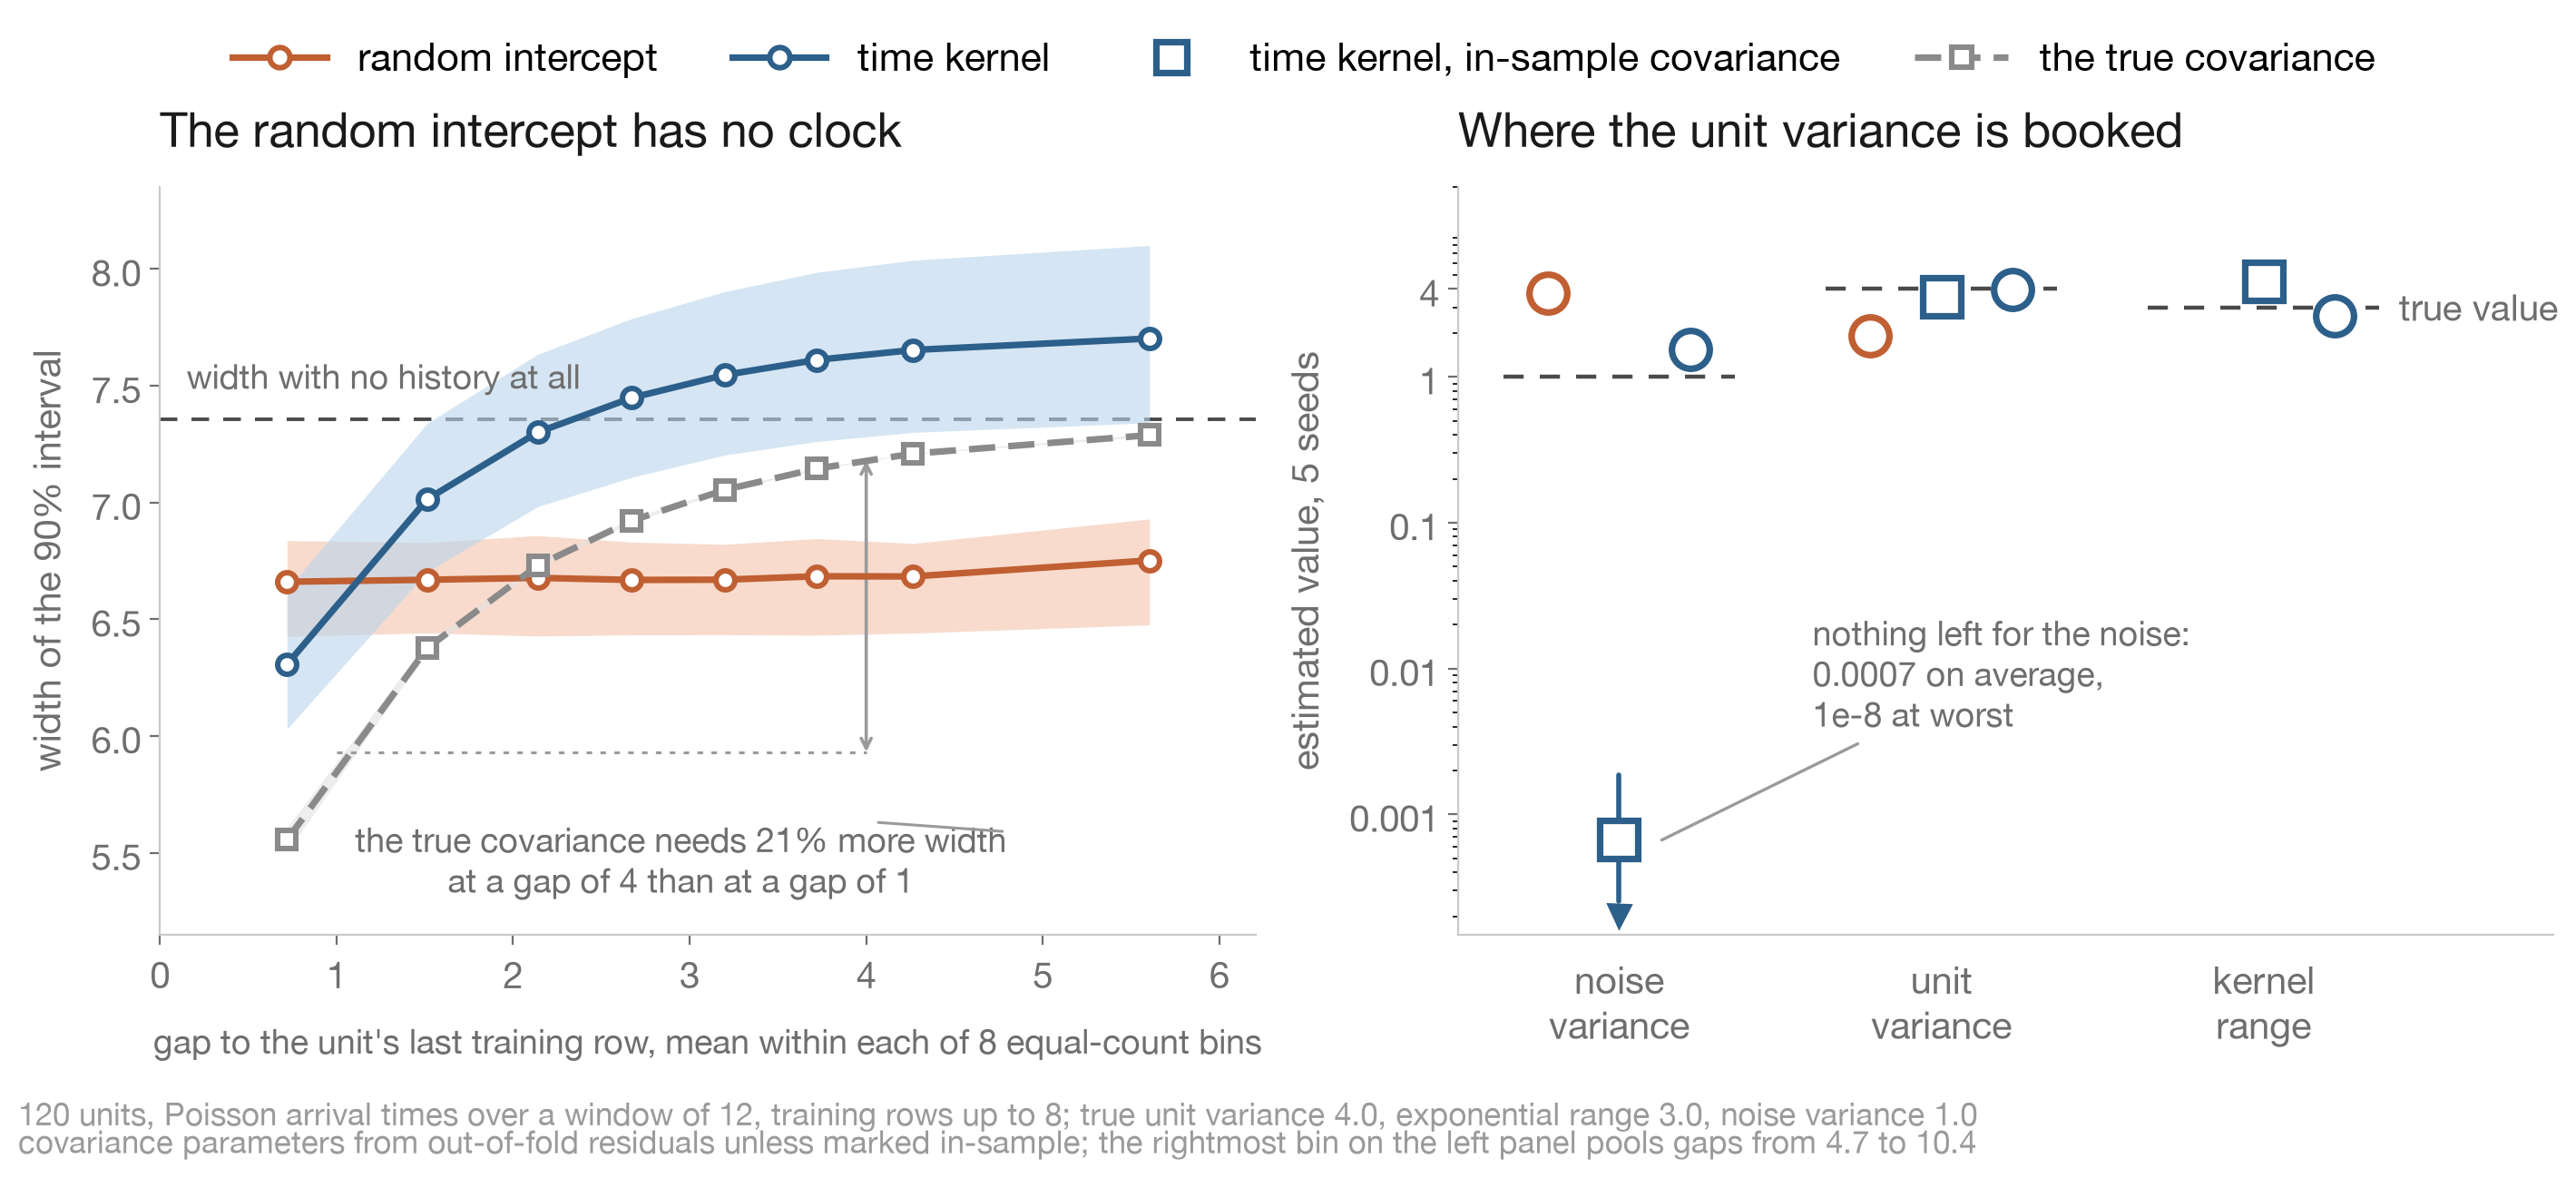

In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_E, BLUE_F = "#2C5F8A", "#B9D5EC"
CORAL_E, CORAL_F = "#C05F32", "#F4C3AC"
GREY_E, GREY_F = "#8a8a8a", "#E2E2E2"
INK, MUTED, FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"
INT, KER, KIN = (NAME["intercept", "oos"], NAME["kernel", "oos"],
                 NAME["kernel", "in-sample"])
NBIN = 8

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.4), dpi=200)
fig.patch.set_facecolor("white")

# left: interval width against the forecast gap
ax = axes[0]
p = P[~P.regular].copy()
edges = qedges(p.gap.values, NBIN)
p["bin"] = pd.cut(p.gap, edges, right=False, labels=False)
SERIES = [(INT, CORAL_E, CORAL_F, "o", "-", "random intercept"),
          (KER, BLUE_E, BLUE_F, "o", "-", "time kernel"),
          ("oracle", GREY_E, GREY_F, "s", (0, (4, 2)), "the true covariance")]
for name, ec, fc, mk, ls, _ in SERIES:
    dd = p[p.model == name]
    per = dd.groupby(["seed", "bin"]).w.mean().unstack("bin")
    x = dd.groupby("bin").gap.mean().values
    ax.fill_between(x, per.min().values, per.max().values, color=fc, alpha=0.6, lw=0, zorder=2)
    ax.plot(x, per.mean().values, color=ec, lw=2.6, ls=ls, marker=mk, ms=7.5, mfc="white",
            mew=2.2, zorder=4)
marg = 2*Z90*np.sqrt(SU**2 + SE**2)
ax.axhline(marg, color="#4a4a4a", lw=1.4, ls=(0, (5, 4)), zorder=1)
ax.text(0.15, marg + 0.10, "width with no history at all", fontsize=13.5, color=MUTED, va="bottom")


oc = p[p.model == "oracle"]
w_near, w_far = win(oc, G_NEAR).w.mean(), win(oc, G_FAR).w.mean()
y0 = 5.15
band_top = max(p[p.model.isin([INT, KER, "oracle"])].groupby(["model", "seed", "bin"]).w.mean().max(),
               marg)
ax.set_xlim(0, max(6.2, x.max() + 0.6))
ax.set_ylim(y0, max(8.35, band_top + 0.25))
ax.plot([G_NEAR, G_FAR], [w_near]*2, color=FAINT, lw=1.1, ls=(0, (2, 3)), zorder=3)
ax.annotate("", xy=(G_FAR, w_near), xytext=(G_FAR, w_far),
            arrowprops=dict(arrowstyle="<->", color=FAINT, lw=1.3, shrinkA=0, shrinkB=0))
ax.text(2.95, y0 + 0.32, f"the true covariance needs {w_far/w_near - 1:.0%} more width\n"
        f"at a gap of {G_FAR:.0f} than at a gap of {G_NEAR:.0f}", fontsize=13.5, color=MUTED,
        va="center", ha="center")
ax.annotate("", xy=(G_FAR + 0.04, w_near - 0.30), xytext=(4.80, y0 + 0.44),
            arrowprops=dict(arrowstyle="-", color=FAINT, lw=1.1, shrinkA=2, shrinkB=2))
ax.set_xlabel(f"gap to the unit's last training row, mean within each of {NBIN} equal-count bins",
              fontsize=13.5, color=MUTED, labelpad=10)
ax.set_ylabel("width of the 90% interval", fontsize=15, color=MUTED, labelpad=9)
ax.set_title("The random intercept has no clock", fontsize=19, color=INK, pad=16, loc="left")

# right: where the unit level variance is booked
ax = axes[1]
GROUPS = [("noise\nvariance", "sigma2", SE**2), ("unit\nvariance", "var_u", SU**2),
          ("kernel\nrange", "range", RHO)]
LEDGER = [(INT, CORAL_E, "o"), (KIN, BLUE_E, "s"), (KER, BLUE_E, "o")]
s_irr = S[~S.regular]
FLOOR = 1.5e-4
off = np.linspace(-0.22, 0.22, len(LEDGER))
for j, (name, ec, mk) in enumerate(LEDGER):
    s = s_irr[s_irr.model == name]
    for i, (_, col, _) in enumerate(GROUPS):
        v = s[col].dropna()
        if not len(v):
            continue
        lo = max(v.min(), FLOOR*1.7)
        ax.plot([i + off[j]]*2, [lo, v.max()], color=ec, lw=2.0, solid_capstyle="round",
                zorder=3)
        if v.min() < FLOOR:                     # the whisker runs off the bottom of the axis
            ax.plot([i + off[j]], [FLOOR*1.35], marker="v", ms=9, mfc=ec, mec=ec, zorder=4)
        ax.plot([i + off[j]], [v.mean()], marker=mk, ms=15, mfc="white", mec=ec, mew=2.6,
                zorder=4)
for i, (_, _, true) in enumerate(GROUPS):
    ax.plot([i - 0.36, i + 0.36], [true]*2, color="#4a4a4a", lw=1.6, ls=(0, (5, 4)), zorder=2)
ax.text(len(GROUPS) - 0.58, RHO, "true value", fontsize=14.5, color=MUTED, va="center",
        ha="left")
ax.set_yscale("log")
ax.set_ylim(FLOOR, 20)
ticks = [1e-3, 1e-2, 1e-1, SE**2, SU**2]
ax.set_yticks(ticks)
ax.set_yticklabels(["%g" % t for t in ticks])
ax.set_xticks(range(len(GROUPS)))
ax.set_xticklabels([g[0] for g in GROUPS])
ax.set_xlim(-0.5, len(GROUPS) - 0.1)
kin = s_irr[s_irr.model == KIN].sigma2
ax.annotate(f"nothing left for the noise:\n{kin.mean():.4f} on average,\n"
            f"{kin.min():.0e} at worst".replace("e-0", "e-"),
            xy=(off[1] + 0.09, 6e-4), xytext=(0.60, 4e-3), fontsize=13.5, color=MUTED,
            arrowprops=dict(arrowstyle="-", color=FAINT, lw=1.2, shrinkA=4, shrinkB=6))
ax.set_ylabel(f"estimated value, {s_irr.seed.nunique()} seeds", fontsize=15, color=MUTED,
              labelpad=9)
ax.set_title("Where the unit variance is booked", fontsize=19, color=INK, pad=16, loc="left")

for ax in axes:
    ax.tick_params(labelsize=14.5, colors=MUTED, length=4)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c9c9c9")
axes[1].tick_params(axis="x", labelsize=15, length=0, pad=9)

handles = [Line2D([], [], color=ec, lw=2.6, ls=ls, marker=mk, ms=8, mfc="white", mew=2.2)
           for _, ec, _, mk, ls, _ in SERIES]
handles.insert(2, Line2D([], [], color=BLUE_E, lw=0, marker="s", ms=12, mfc="white", mew=2.6))
labels = [lab for *_, lab in SERIES]
labels.insert(2, "time kernel, in-sample covariance")
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, fontsize=15.5,
           bbox_to_anchor=(0.5, 1.0), handlelength=2.4, columnspacing=1.9)
fig.text(0.008, 0.030, f"{NG} units, Poisson arrival times over a window of {T_WIN:.0f}, "
         f"training rows up to {T_CUT:.0f}; true unit variance {SU**2:.1f}, exponential range "
         f"{RHO:.1f}, noise variance {SE**2:.1f}", fontsize=12.5, color=FAINT, ha="left")
fig.text(0.008, 0.006, "covariance parameters from out-of-fold residuals unless marked "
         f"in-sample; the rightmost bin on the left panel pools gaps from {edges[-2]:.1f} to "
         f"{p.gap.max():.1f}", fontsize=12.5, color=FAINT, ha="left")
fig.tight_layout(rect=[0, 0.062, 1, 0.935])
fig.savefig("panel_irregular_kernel.png", facecolor="white")
plt.show()

## What this measured

A random intercept on this panel is worth almost nothing: it beats a LightGBM with no unit
structure at all by about two percent of RMSE, because it is fitting the wrong covariance. The same
random effect with a clock is worth ten percent at this setting, and closes about sixty percent of
the distance from the random intercept to a model that knows the truth. Both of those gains change
sign across the tuning sweep; what does not is that the kernel beats the intercept every time.

The variance decomposition is where the assumption becomes visible. Estimated from out-of-fold
residuals, the intercept reports about half of the unit level variance and inflates the noise
variance nearly fourfold. The first of those is predictable in advance from the average within-unit
correlation; the second needs the trees' own out-of-fold error added to it, which is measured
rather than known. Even a correctly specified covariance reports more noise than there is: the
kernel reads 1.54 against a true 1.0, and 1.0 plus its own out-of-fold error of 0.48 accounts for
most of that. Read a fitted noise variance against that sum rather than against the measurement
noise alone, and take what is left over as a misspecification report, which is the reading part 5
arrived at from a different direction.

Estimating covariance parameters in-sample is worse here than it was in part 4. A flexible kernel
has somewhere to put the residual variance the trees have already absorbed, so the noise variance
goes to zero and the range stretches by half. Out-of-fold residuals fix it.

The interval is the part that generalises past this simulation. A random effect with no notion of
distance in time produces a prediction interval with no horizon term, and on an irregular panel the
held-out rows sit at many horizons, so a single coverage number is applied to an interval that is
wider than it should be at one end and narrower at the other. Plot width against horizon rather
than reading coverage alone.

One measurement note worth carrying over. How much wider the interval should get depends on which
two horizons you compare, and binning the held-out rows into equal-count buckets hides that choice
inside the bin count: on this panel the same quantity reads 12% with two bins and 43% with twenty.
Naming the horizons instead makes the number reproducible.